/tmp/ipykernel_1788/2528076956.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2021-01-01', end='2025-01-01')
[*********************100%***********************]  5 of 5 completed


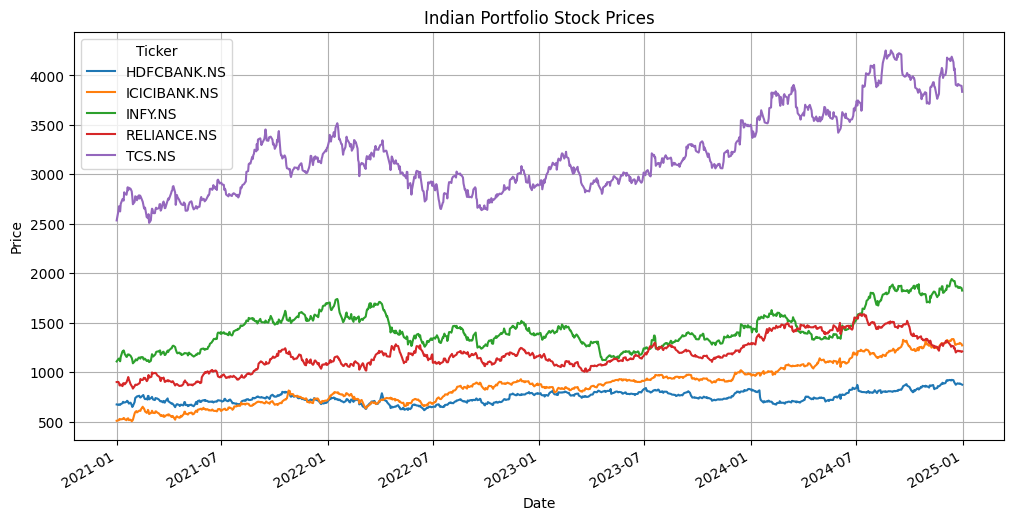

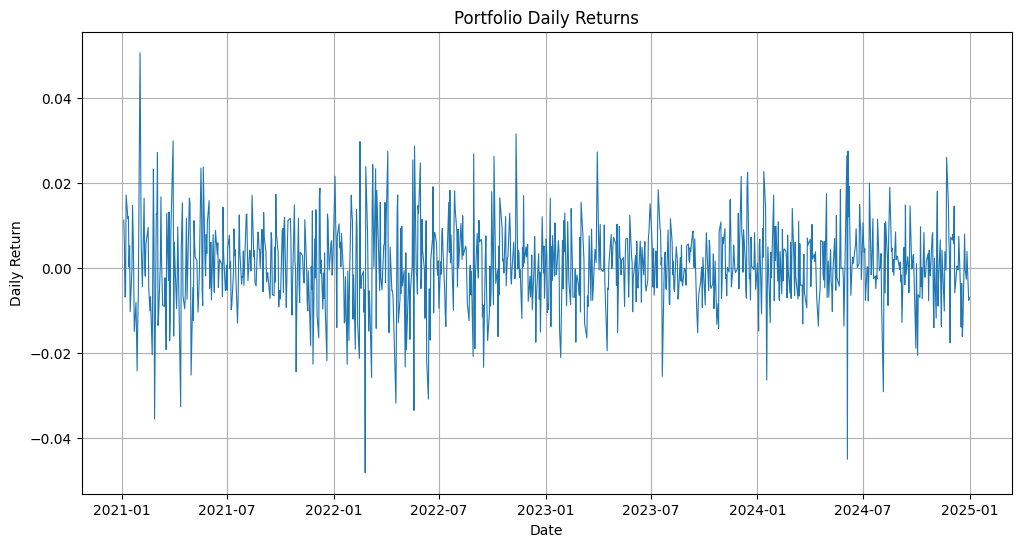

95% Historical VaR: -0.0149
99% Historical VaR: -0.0256
95% VaR in Rupees: ₹14,944.01
99% VaR in Rupees: ₹25,562.12


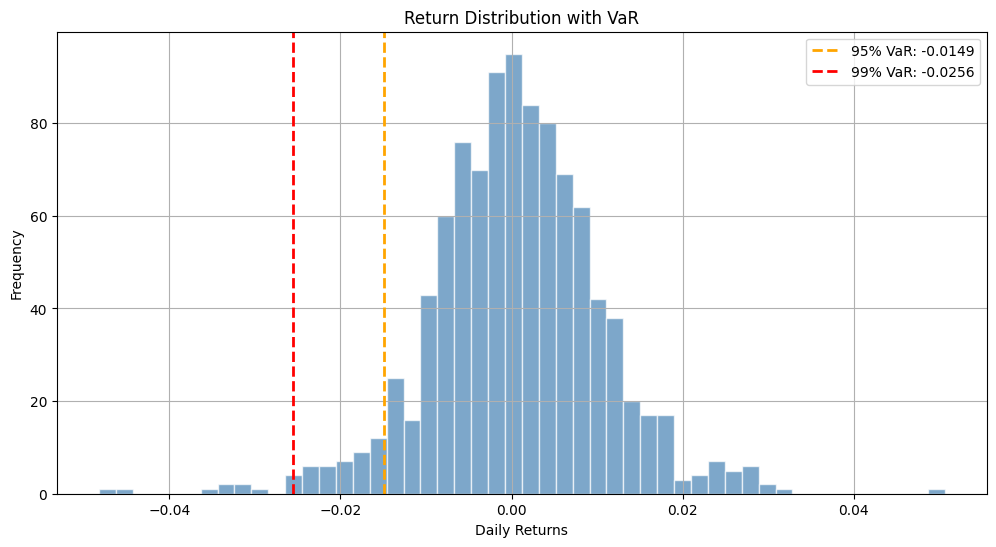

95% Expected Shortfall: -0.0221
99% Expected Shortfall: -0.0339
95% ES in Rupees: ₹22,141.32
99% ES in Rupees: ₹33,909.75


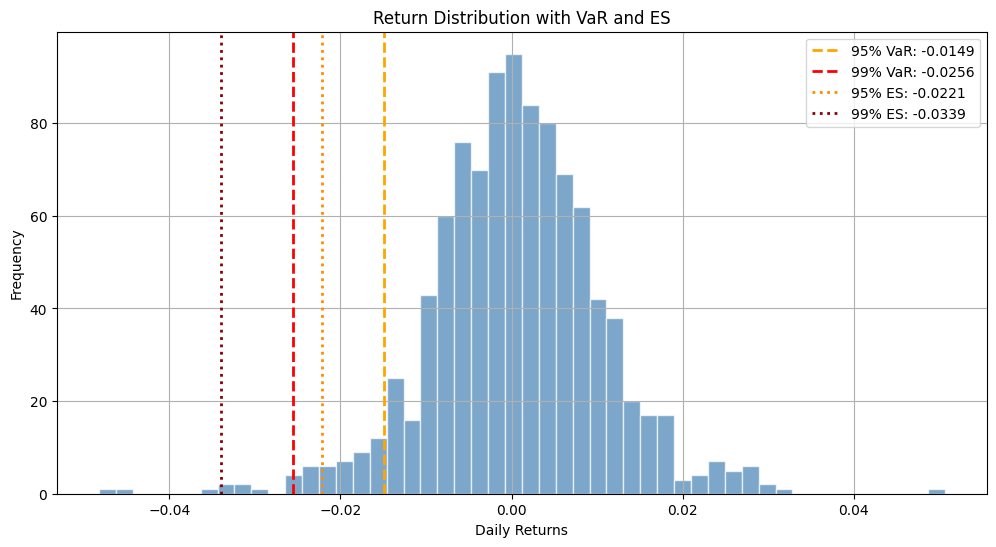

Mean Daily Return: 0.000573
Daily Volatility: 0.009948
Annualised Volatility: 15.79%
Monte Carlo 95% VaR: -0.0158
Monte Carlo 99% VaR: -0.0223
Monte Carlo 95% ES: -0.0199
Monte Carlo 99% ES: -0.0260


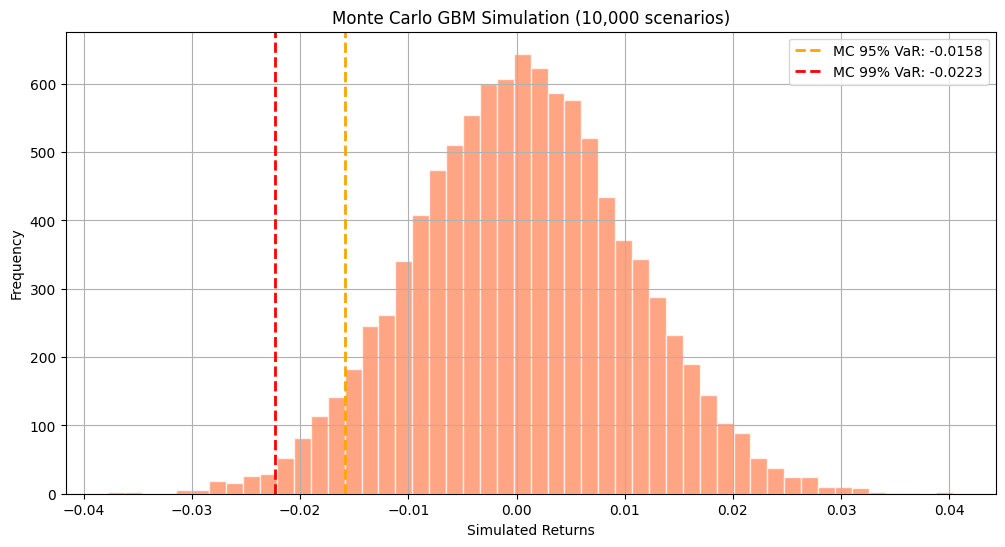


Historical vs Monte Carlo
Historical 95% VaR:  -0.0149   |   MC 95% VaR:  -0.0158
Historical 99% VaR:  -0.0256   |   MC 99% VaR:  -0.0223
Historical 95% ES:   -0.0221   |   MC 95% ES:   -0.0199
Historical 99% ES:   -0.0339   |   MC 99% ES:   -0.0260

              Metric     Value  Rupee Impact (10L)
 Historical VaR 95% -0.014944        14944.005992
 Historical VaR 99% -0.025562        25562.115285
  Historical ES 95% -0.022141        22141.324539
  Historical ES 99% -0.033910        33909.745529
Monte Carlo VaR 95% -0.015813        15812.780714
Monte Carlo VaR 99% -0.022309        22308.930194
 Monte Carlo ES 95% -0.019915        19914.583598
 Monte Carlo ES 99% -0.025957        25957.086284


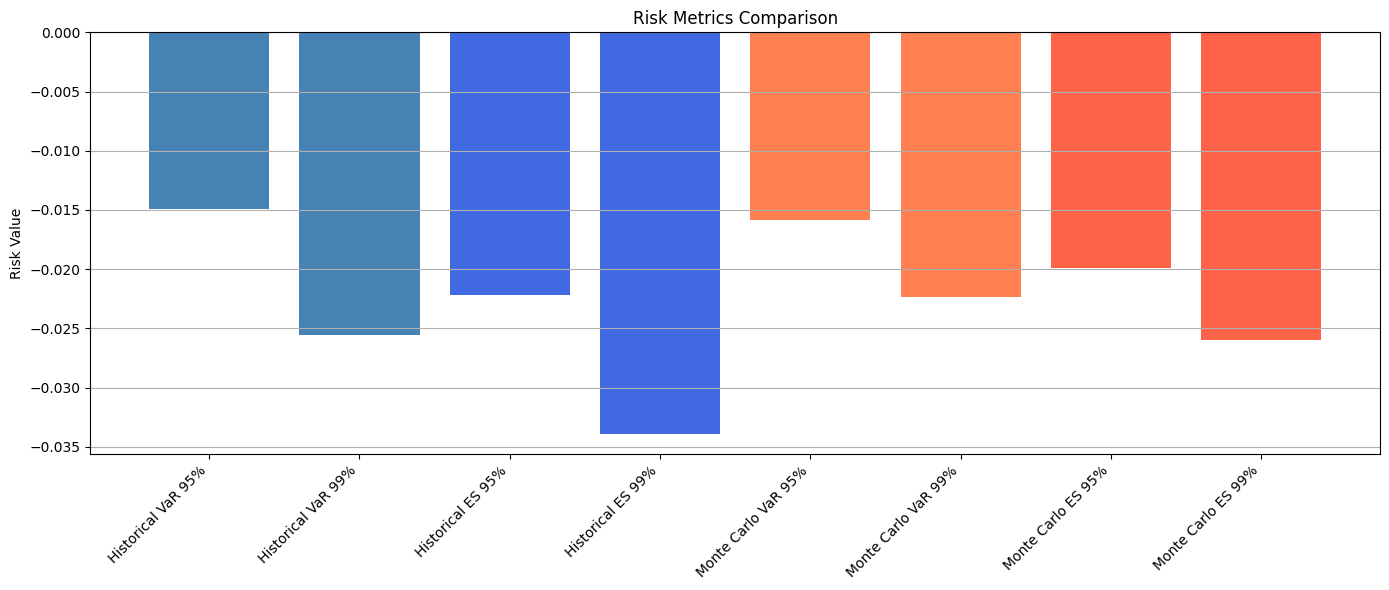

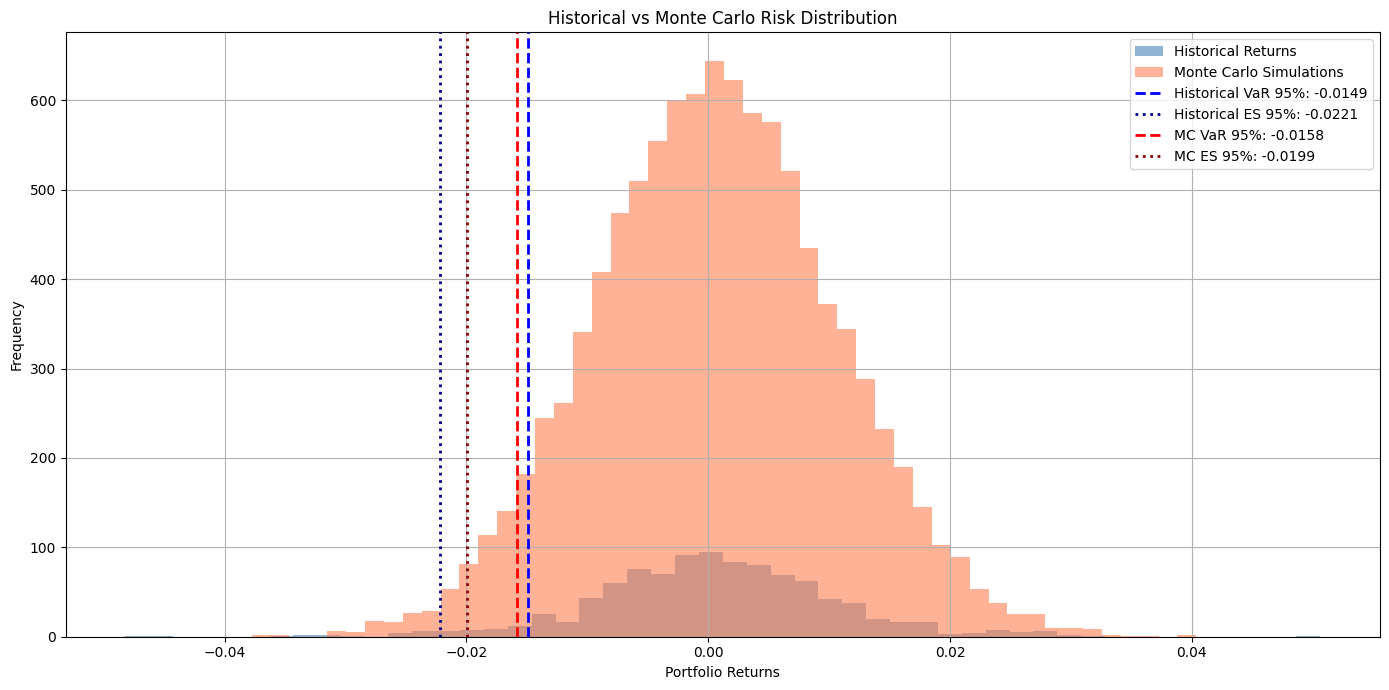


Saved to risk_metrics_project2.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

np.random.seed(42)

# downloading data for 5 large indian stocks
stocks = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS']
data = yf.download(stocks, start='2021-01-01', end='2025-01-01')
prices = data['Close']

prices.plot(figsize=(12, 6))
plt.title('Indian Portfolio Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

# daily returns
returns = prices.pct_change().dropna()

# weights across 5 stocks, sums to 1
weights = np.array([0.25, 0.20, 0.15, 0.20, 0.20])

portfolio_returns = returns.dot(weights)

plt.figure(figsize=(12, 6))
plt.plot(portfolio_returns, linewidth=0.8)
plt.title('Portfolio Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.show()

# historical var
# 5th percentile gives 95% var, 1st percentile gives 99% var
var_95 = np.percentile(portfolio_returns, 5)
var_99 = np.percentile(portfolio_returns, 1)

print(f"95% Historical VaR: {var_95:.4f}")
print(f"99% Historical VaR: {var_99:.4f}")

# converting to rupees on a 10 lakh portfolio
portfolio_value = 1_000_000
rupee_var_95 = portfolio_value * abs(var_95)
rupee_var_99 = portfolio_value * abs(var_99)

print(f"95% VaR in Rupees: ₹{rupee_var_95:,.2f}")
print(f"99% VaR in Rupees: ₹{rupee_var_99:,.2f}")

plt.figure(figsize=(12, 6))
plt.hist(portfolio_returns, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR: {var_95:.4f}')
plt.axvline(var_99, color='red', linestyle='--', linewidth=2, label=f'99% VaR: {var_99:.4f}')
plt.title('Return Distribution with VaR')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# expected shortfall = average of losses beyond var threshold
# should always be more negative than var
es_95 = portfolio_returns[portfolio_returns <= var_95].mean()
es_99 = portfolio_returns[portfolio_returns <= var_99].mean()

print(f"95% Expected Shortfall: {es_95:.4f}")
print(f"99% Expected Shortfall: {es_99:.4f}")

rupee_es_95 = portfolio_value * abs(es_95)
rupee_es_99 = portfolio_value * abs(es_99)

print(f"95% ES in Rupees: ₹{rupee_es_95:,.2f}")
print(f"99% ES in Rupees: ₹{rupee_es_99:,.2f}")

plt.figure(figsize=(12, 6))
plt.hist(portfolio_returns, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR: {var_95:.4f}')
plt.axvline(var_99, color='red', linestyle='--', linewidth=2, label=f'99% VaR: {var_99:.4f}')
plt.axvline(es_95, color='darkorange', linestyle=':', linewidth=2, label=f'95% ES: {es_95:.4f}')
plt.axvline(es_99, color='darkred', linestyle=':', linewidth=2, label=f'99% ES: {es_99:.4f}')
plt.title('Return Distribution with VaR and ES')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# monte carlo using geometric brownian motion
# gbm formula accounts for drift and randomness
# the 0.5*sigma^2 term is the ito correction for compounding
mean_return = portfolio_returns.mean()
volatility = portfolio_returns.std()

print(f"Mean Daily Return: {mean_return:.6f}")
print(f"Daily Volatility: {volatility:.6f}")
print(f"Annualised Volatility: {volatility * np.sqrt(252) * 100:.2f}%")

num_simulations = 10_000
dt = 1
S0 = 1

Z = np.random.normal(0, 1, num_simulations)

# gbm: S1 = S0 * exp((mu - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
simulated_prices = S0 * np.exp(
    (mean_return - 0.5 * volatility**2) * dt +
    volatility * np.sqrt(dt) * Z
)

simulated_returns = simulated_prices - 1

mc_var_95 = np.percentile(simulated_returns, 5)
mc_var_99 = np.percentile(simulated_returns, 1)

mc_es_95 = simulated_returns[simulated_returns <= mc_var_95].mean()
mc_es_99 = simulated_returns[simulated_returns <= mc_var_99].mean()

print(f"Monte Carlo 95% VaR: {mc_var_95:.4f}")
print(f"Monte Carlo 99% VaR: {mc_var_99:.4f}")
print(f"Monte Carlo 95% ES: {mc_es_95:.4f}")
print(f"Monte Carlo 99% ES: {mc_es_99:.4f}")

plt.figure(figsize=(12, 6))
plt.hist(simulated_returns, bins=50, color='coral', alpha=0.7, edgecolor='white')
plt.axvline(mc_var_95, color='orange', linestyle='--', linewidth=2, label=f'MC 95% VaR: {mc_var_95:.4f}')
plt.axvline(mc_var_99, color='red', linestyle='--', linewidth=2, label=f'MC 99% VaR: {mc_var_99:.4f}')
plt.title('Monte Carlo GBM Simulation (10,000 scenarios)')
plt.xlabel('Simulated Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

# comparing both approaches side by side
print("\nHistorical vs Monte Carlo")
print(f"Historical 95% VaR:  {var_95:.4f}   |   MC 95% VaR:  {mc_var_95:.4f}")
print(f"Historical 99% VaR:  {var_99:.4f}   |   MC 99% VaR:  {mc_var_99:.4f}")
print(f"Historical 95% ES:   {es_95:.4f}   |   MC 95% ES:   {mc_es_95:.4f}")
print(f"Historical 99% ES:   {es_99:.4f}   |   MC 99% ES:   {mc_es_99:.4f}")

# summary table
risk_metrics = pd.DataFrame({
    'Metric': [
        'Historical VaR 95%', 'Historical VaR 99%',
        'Historical ES 95%', 'Historical ES 99%',
        'Monte Carlo VaR 95%', 'Monte Carlo VaR 99%',
        'Monte Carlo ES 95%', 'Monte Carlo ES 99%'
    ],
    'Value': [
        var_95, var_99, es_95, es_99,
        mc_var_95, mc_var_99, mc_es_95, mc_es_99
    ],
    'Rupee Impact (10L)': [
        rupee_var_95, rupee_var_99,
        rupee_es_95, rupee_es_99,
        portfolio_value * abs(mc_var_95),
        portfolio_value * abs(mc_var_99),
        portfolio_value * abs(mc_es_95),
        portfolio_value * abs(mc_es_99)
    ]
})

print("\n", risk_metrics.to_string(index=False))

# bar chart
plt.figure(figsize=(14, 6))
colors = ['steelblue', 'steelblue', 'royalblue', 'royalblue',
          'coral', 'coral', 'tomato', 'tomato']
plt.bar(risk_metrics['Metric'], risk_metrics['Value'], color=colors)
plt.title('Risk Metrics Comparison')
plt.ylabel('Risk Value')
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# combined plot — historical returns vs monte carlo simulations
plt.figure(figsize=(14, 7))
plt.hist(portfolio_returns, bins=50, alpha=0.6, color='steelblue', label='Historical Returns')
plt.hist(simulated_returns, bins=50, alpha=0.6, color='coral', label='Monte Carlo Simulations')
plt.axvline(var_95, color='blue', linestyle='--', linewidth=2, label=f'Historical VaR 95%: {var_95:.4f}')
plt.axvline(es_95, color='darkblue', linestyle=':', linewidth=2, label=f'Historical ES 95%: {es_95:.4f}')
plt.axvline(mc_var_95, color='red', linestyle='--', linewidth=2, label=f'MC VaR 95%: {mc_var_95:.4f}')
plt.axvline(mc_es_95, color='darkred', linestyle=':', linewidth=2, label=f'MC ES 95%: {mc_es_95:.4f}')
plt.title('Historical vs Monte Carlo Risk Distribution')
plt.xlabel('Portfolio Returns')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# save results
risk_metrics.to_csv('risk_metrics_project2.csv', index=False)
print("\nSaved to risk_metrics_project2.csv")